# Imports

In [1]:
import pandas            as pd
import matplotlib.pyplot as plt
import numpy             as np
import matplotlib.colors as colors

import matplotlib
import sys

sys.path.append('/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk')

# Import Diego's tools
from WCTE_event_display.EventDisplay import EventDisplay
from WCSimFilePackages.npz_to_df     import simple_truehits_info_to_df, truehits_info_to_df, digihits_info_to_df
from WCSimFilePackages.npz_to_df     import super_simple_track_info_to_df, simple_track_info_to_df, track_info_to_df

from tqdm.notebook import tqdm

import hipy.hipy.pltext as pltext

%load_ext autoreload
%autoreload 2

pltext.style()

# Read Data

In [38]:
df_cands = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/mc/candidates_df_tofCorr.csv")

In [4]:
npz_1767 = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/rootFiles/1Mneutrons_NiCf_piFix_QGSP_BIC_HP_pos1767_CDSON_15kevents.npz'
nevents  = 15000

# Creación del DataFrame de DigiHits usando la función digihits_info_to_df
df_trueHits_1767 = truehits_info_to_df(npz_1767).dropna()
df_tracks_1767   = track_info_to_df(npz_1767).dropna()

df_tracks_1767["type"] = None

mask_nCapture_gamma = (df_tracks_1767["track_pid"] == 22) & (df_tracks_1767["track_creator_process"] == "nCapture")
mask_H = mask_nCapture_gamma & (df_tracks_1767["track_energy"] >= 2.20) & (df_tracks_1767["track_energy"] <= 2.25)
mask_Ni = mask_nCapture_gamma & ~mask_H

df_tracks_1767.loc[mask_H, "type"]  = "H"
df_tracks_1767.loc[mask_Ni, "type"] = "Ni"

print(df_tracks_1767["type"].value_counts(dropna=False))

type
None    27806287
H          48517
Ni         18874
Name: count, dtype: int64


# tRMS

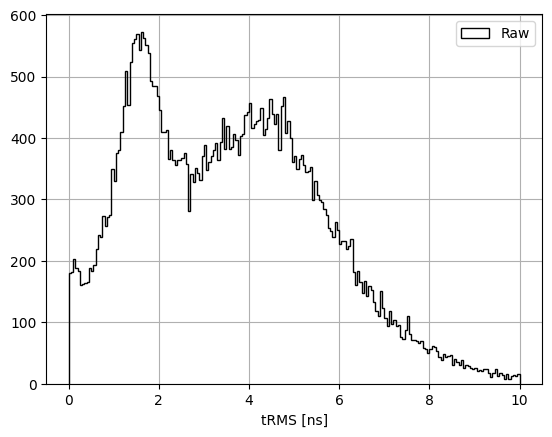

In [40]:
pltext.hist(df_cands["trms"],                           bins=200, ylog=False, stats=False, range=(0, 10), xylabels="tRMS [ns]", label='Raw');
# pltext.hist(df_cands["trms_corrected_source"].dropna(), bins=200, ylog=False, stats=False, range=(0, 10), xylabels="tRMS [ns]", label='ToF to source');
# pltext.hist(df_cands["trms_corrected_vertex"].dropna(), bins=200, ylog=False, stats=False, range=(0, 10), xylabels="tRMS [ns]", label='ToF to true vertex');

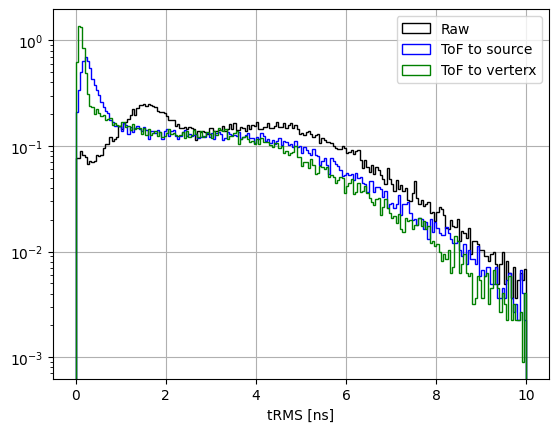

In [28]:
pltext.hist(df_cands[df_cands["capture_type"].values == "H"]["trms"].dropna(),                  200, density=True, ylog=True, range=(0,10), stats=False, xylabels="tRMS [ns]", label='Raw');
pltext.hist(df_cands[df_cands["capture_type"].values == "H"]["trms_corrected_source"].dropna(), 200, density=True, ylog=True, range=(0,10), stats=False, xylabels="tRMS [ns]", label='ToF to source');
pltext.hist(df_cands[df_cands["capture_type"].values == "H"]["trms_corrected_vertex"].dropna(), 200, density=True, ylog=True, range=(0,10), stats=False, xylabels="tRMS [ns]", label='ToF to verterx');

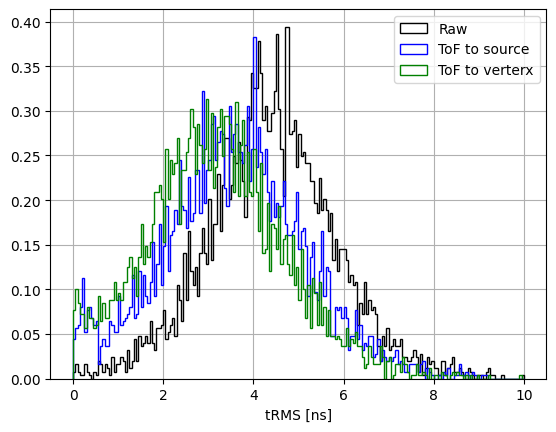

In [30]:
pltext.hist(df_cands[df_cands["capture_type"].values == "Ni"]["trms"].dropna(),                  200, density=True, ylog=False, range=(0,10), stats=False, xylabels="tRMS [ns]", label='Raw');
pltext.hist(df_cands[df_cands["capture_type"].values == "Ni"]["trms_corrected_source"].dropna(), 200, density=True, ylog=False, range=(0,10), stats=False, xylabels="tRMS [ns]", label='ToF to source');
pltext.hist(df_cands[df_cands["capture_type"].values == "Ni"]["trms_corrected_vertex"].dropna(), 200, density=True, ylog=False, range=(0,10), stats=False, xylabels="tRMS [ns]", label='ToF to verterx');

# tRMS vs.

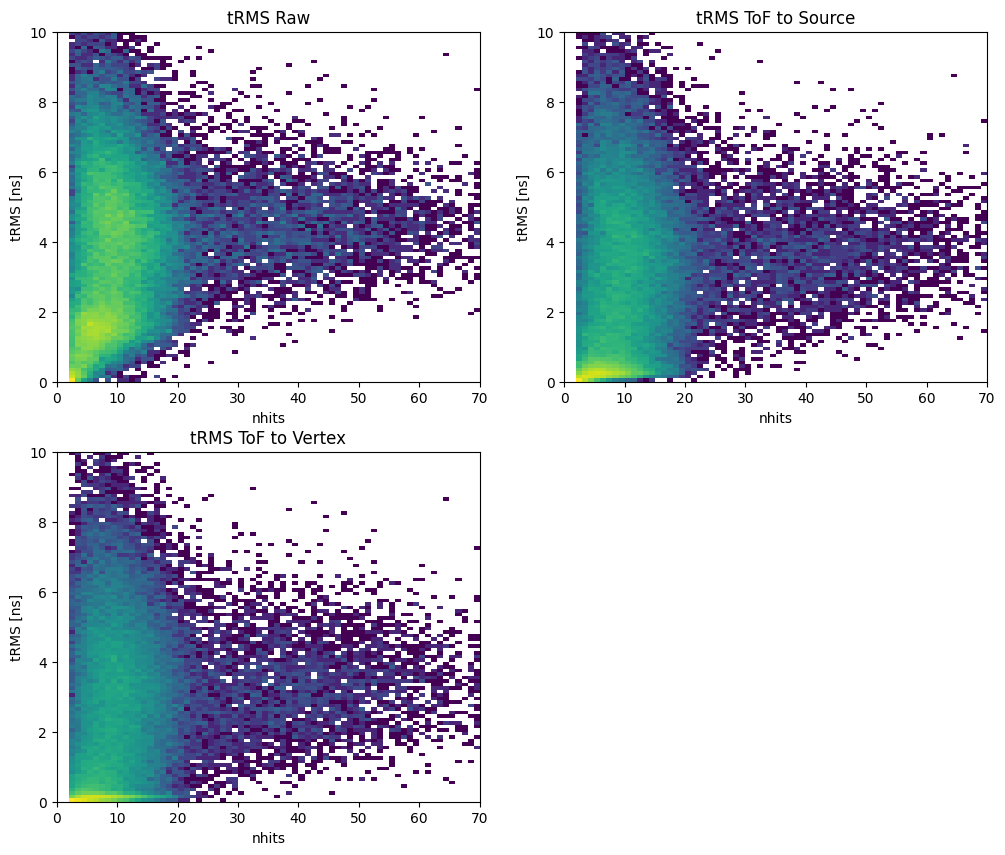

In [21]:
subplot = pltext.canvas(3)

subplot(1)
plt.title("tRMS Raw")
plt.hist2d(df_cands["nhits"].values, df_cands["trms"].values, (70, 100), range=((0,70), (0,10)), norm="log");
plt.xlabel("nhits"),
plt.ylabel("tRMS [ns]");

subplot(2)
plt.title("tRMS ToF to Source")
plt.hist2d(df_cands["nhits"].values, df_cands["trms_corrected_source"].values, (70, 100), range=((0,70), (0,10)), norm="log");
plt.xlabel("nhits"),
plt.ylabel("tRMS [ns]");

subplot(3)
plt.title("tRMS ToF to Vertex")
plt.hist2d(df_cands["nhits"].values, df_cands["trms_corrected_vertex"].values, (70, 100), range=((0,70), (0,10)), norm="log");
plt.xlabel("nhits"),
plt.ylabel("tRMS [ns]");

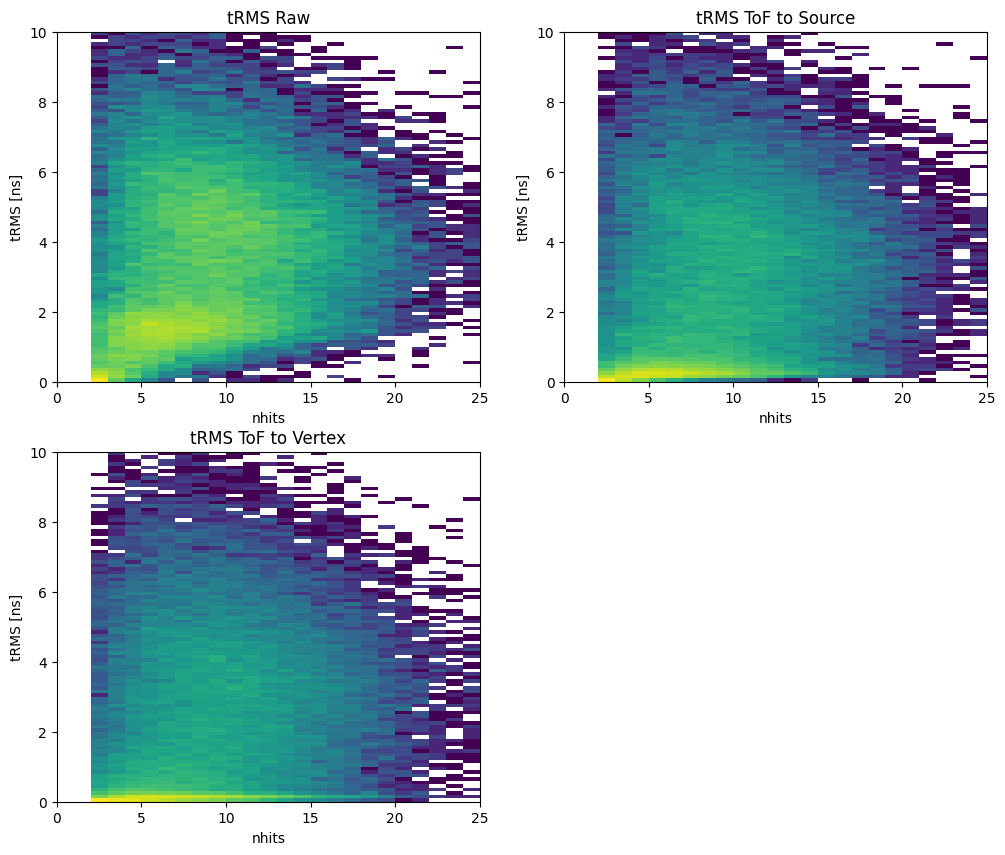

In [23]:
subplot = pltext.canvas(3)

subplot(1)
plt.title("tRMS Raw")
plt.hist2d(df_cands[df_cands["capture_type"].values == "H"]["nhits"].values, df_cands[df_cands["capture_type"].values == "H"]["trms"].values, (25, 100), range=((0,25), (0,10)), norm="log");
plt.xlabel("nhits"),
plt.ylabel("tRMS [ns]");

subplot(2)
plt.title("tRMS ToF to Source")
plt.hist2d(df_cands[df_cands["capture_type"].values == "H"]["nhits"].values, df_cands[df_cands["capture_type"].values == "H"]["trms_corrected_source"].values, (25, 100), range=((0,25), (0,10)), norm="log");
plt.xlabel("nhits"),
plt.ylabel("tRMS [ns]");

subplot(3)
plt.title("tRMS ToF to Vertex")
plt.hist2d(df_cands[df_cands["capture_type"].values == "H"]["nhits"].values, df_cands[df_cands["capture_type"].values == "H"]["trms_corrected_vertex"].values, (25, 100), range=((0,25), (0,10)), norm="log");
plt.xlabel("nhits"),
plt.ylabel("tRMS [ns]");

In [ ]:
# --- Plots ---
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Row 1: residual distributions
all_res_H  = np.concatenate(df_refl[df_refl["capture_type"] == "H"]["residuals"].values)
all_res_Ni = np.concatenate(df_refl[df_refl["capture_type"] == "Ni"]["residuals"].values)

axes[0, 0].hist(all_res_H,  bins=200, range=(-5, 20), density=True,
                histtype='step', color='blue', linewidth=1.5, label=f'H ({len(all_res_H)})')
axes[0, 0].hist(all_res_Ni, bins=200, range=(-5, 20), density=True,
                histtype='step', color='red', linewidth=1.5, label=f'Ni ({len(all_res_Ni)})')
axes[0, 0].axvline(2.0, color='green', linestyle='--', label='Reflection threshold (2 ns)')
axes[0, 0].set_xlabel("Time residual [ns]")
axes[0, 0].set_ylabel("PDF")
axes[0, 0].set_title("Hit time residual (actual - expected direct)")
axes[0, 0].legend()
axes[0, 0].grid(True)

# Fraction reflected per candidate
axes[0, 1].hist(df_refl[df_refl["capture_type"] == "H"]["frac_reflected"], 
                bins=50, range=(0, 1), density=True, histtype='step', 
                color='blue', linewidth=1.5, label='H')
axes[0, 1].hist(df_refl[df_refl["capture_type"] == "Ni"]["frac_reflected"], 
                bins=50, range=(0, 1), density=True, histtype='step', 
                color='red', linewidth=1.5, label='Ni')
axes[0, 1].set_xlabel("Fraction of reflected hits per candidate")
axes[0, 1].set_ylabel("PDF")
axes[0, 1].set_title("Reflected hit fraction")
axes[0, 1].legend()
axes[0, 1].grid(True)

# N reflected vs nhits
axes[0, 2].scatter(df_refl[df_refl["capture_type"] == "H"]["nhits"],
                   df_refl[df_refl["capture_type"] == "H"]["n_reflected"],
                   s=2, alpha=0.3, color='blue', label='H')
axes[0, 2].scatter(df_refl[df_refl["capture_type"] == "Ni"]["nhits"],
                   df_refl[df_refl["capture_type"] == "Ni"]["n_reflected"],
                   s=2, alpha=0.3, color='red', label='Ni')
axes[0, 2].set_xlabel("N hits per candidate")
axes[0, 2].set_ylabel("N reflected hits")
axes[0, 2].set_title("N reflected vs N hits")
axes[0, 2].legend()
axes[0, 2].grid(True)

# Row 2: impact on tRMS
axes[1, 0].scatter(df_refl[df_refl["capture_type"] == "H"]["frac_reflected"],
                   df_refl[df_refl["capture_type"] == "H"]["trms_corrected_vertex"],
                   s=2, alpha=0.3, color='blue', label='H')
axes[1, 0].scatter(df_refl[df_refl["capture_type"] == "Ni"]["frac_reflected"],
                   df_refl[df_refl["capture_type"] == "Ni"]["trms_corrected_vertex"],
                   s=2, alpha=0.3, color='red', label='Ni')
axes[1, 0].set_xlabel("Fraction reflected")
axes[1, 0].set_ylabel("$t_{RMS}$ vertex-corrected [ns]")
axes[1, 0].set_title("Reflection fraction vs tRMS (vertex corrected)")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].scatter(df_refl[df_refl["capture_type"] == "H"]["max_residual"],
                   df_refl[df_refl["capture_type"] == "H"]["trms_corrected_vertex"],
                   s=2, alpha=0.3, color='blue', label='H')
axes[1, 1].scatter(df_refl[df_refl["capture_type"] == "Ni"]["max_residual"],
                   df_refl[df_refl["capture_type"] == "Ni"]["trms_corrected_vertex"],
                   s=2, alpha=0.3, color='red', label='Ni')
axes[1, 1].set_xlabel("Max residual [ns]")
axes[1, 1].set_ylabel("$t_{RMS}$ vertex-corrected [ns]")
axes[1, 1].set_title("Max residual vs tRMS (vertex corrected)")
axes[1, 1].legend()
axes[1, 1].grid(True)

# nhits vs tRMS vertex corrected, colored by frac_reflected
sc = axes[1, 2].scatter(df_refl["nhits"], df_refl["trms_corrected_vertex"], 
                         s=2, alpha=0.3, c=df_refl["frac_reflected"], cmap='hot_r')
axes[1, 2].set_xlabel("N hits")
axes[1, 2].set_ylabel("$t_{RMS}$ vertex-corrected [ns]")
axes[1, 2].set_title("nhits vs tRMS, colored by reflection fraction")
fig.colorbar(sc, ax=axes[1, 2], label="Frac reflected")
axes[1, 2].grid(True)

plt.tight_layout()
plt.show()

# Reflections?

In [13]:
c_water = 21.77  # cm/ns

def analyze_reflections(df_cands_100, df_tracks, df_hits, event_ids):
    """
    For each hit in each candidate:
    - Compute expected direct ToF: dist(vertex → PMT) / c_water
    - Compute time residual: (hit_time - vertex_emission_time) - expected_ToF
    - A large positive residual suggests a reflected photon
    """
    
    all_results = []
    
    for event_id in tqdm(event_ids, total=len(event_ids)):
        
        ev_tracks = df_tracks[df_tracks["event_id"] == event_id]
        ev_hits   = df_hits[df_hits["event_id"] == event_id]
        ev_cands  = df_cands_100[df_cands_100["event_id"] == event_id]
        
        # Build parent_id → (vx, vy, vz, t_emission)
        vertex_map = {}
        for _, row in ev_tracks[ev_tracks["track_pid"].isin([11, -11])].iterrows():
            vertex_map[row["track_id"]] = (float(row["track_xi"]),
                                            float(row["track_yi"]),
                                            float(row["track_zi"]),
                                            float(row["track_ti"]))
        
        hit_times   = ev_hits["true_hit_time"].values
        hit_parents = ev_hits["true_hit_parent"].values
        hit_x       = ev_hits["hit_x"].values.astype(np.float64)
        hit_y       = ev_hits["hit_y"].values.astype(np.float64)
        hit_z       = ev_hits["hit_z"].values.astype(np.float64)
        
        for _, cand in ev_cands.iterrows():
            raw_times = cand["all_times"]
            if isinstance(raw_times, str):
                raw_times = eval(raw_times)
            cand_times = np.array(raw_times, dtype=np.float64)
            
            residuals = []
            is_reflected = []
            
            for t in cand_times:
                idx = np.argmin(np.abs(hit_times - t))
                if np.abs(hit_times[idx] - t) > 1e-3:
                    continue
                
                pid = hit_parents[idx]
                if pid not in vertex_map:
                    continue
                
                vx, vy, vz, t_emit = vertex_map[pid]
                hx, hy, hz = hit_x[idx], hit_y[idx], hit_z[idx]
                
                # Direct distance and expected ToF
                dist_direct = np.sqrt((hx - vx)**2 + (hy - vy)**2 + (hz - vz)**2)
                tof_direct  = dist_direct / c_water
                
                # Actual travel time
                t_travel = hit_times[idx] - t_emit
                
                # Residual: excess time beyond direct path
                residual = t_travel - tof_direct
                
                residuals.append(residual)
                # A reflected photon travels at least ~2x the direct path
                # Conservative threshold: residual > 2 ns (~44 cm extra path)
                is_reflected.append(residual > 2.0)
            
            residuals = np.array(residuals)
            is_reflected = np.array(is_reflected)
            n_hits_matched = len(residuals)
            
            if n_hits_matched == 0:
                all_results.append({
                    "candidate_id"     : cand["candidate_id"],
                    "capture_type"     : cand["capture_type"],
                    "nhits"            : cand["nhits"],
                    "trms"             : cand["trms"],
                    "trms_corrected_vertex": cand["trms_corrected_vertex"],
                    "n_reflected"      : 0,
                    "frac_reflected"   : 0.0,
                    "mean_residual"    : np.nan,
                    "max_residual"     : np.nan,
                    "residuals"        : [],
                })
                continue
            
            all_results.append({
                "candidate_id"     : cand["candidate_id"],
                "capture_type"     : cand["capture_type"],
                "nhits"            : cand["nhits"],
                "trms"             : cand["trms"],
                "trms_corrected_vertex": cand["trms_corrected_vertex"],
                "n_reflected"      : is_reflected.sum(),
                "frac_reflected"   : is_reflected.mean(),
                "mean_residual"    : residuals.mean(),
                "max_residual"     : residuals.max(),
                "residuals"        : list(residuals),
            })
    
    return pd.DataFrame(all_results)


df_refl = analyze_reflections(df_cands, df_tracks_1767, df_trueHits_1767, range(1000))

# --- Stats ---
for ct in ["H", "Ni"]:
    sub = df_refl[df_refl["capture_type"] == ct]
    print(f"\n--- {ct}-capture ---")
    print(f"  Candidates:           {len(sub)}")
    print(f"  Mean frac reflected:  {sub['frac_reflected'].mean():.3f}")
    print(f"  Mean n reflected:     {sub['n_reflected'].mean():.2f}")
    print(f"  Mean max residual:    {sub['max_residual'].mean():.2f} ns")
    print(f"  Mean tRMS vertex:     {sub['trms_corrected_vertex'].mean():.3f} ns")

  0%|          | 0/1000 [00:00<?, ?it/s]


--- H-capture ---
  Candidates:           2950
  Mean frac reflected:  0.141
  Mean n reflected:     1.19
  Mean max residual:    6.88 ns
  Mean tRMS vertex:     2.294 ns

--- Ni-capture ---
  Candidates:           279
  Mean frac reflected:  0.142
  Mean n reflected:     4.70
  Mean max residual:    14.29 ns
  Mean tRMS vertex:     3.251 ns


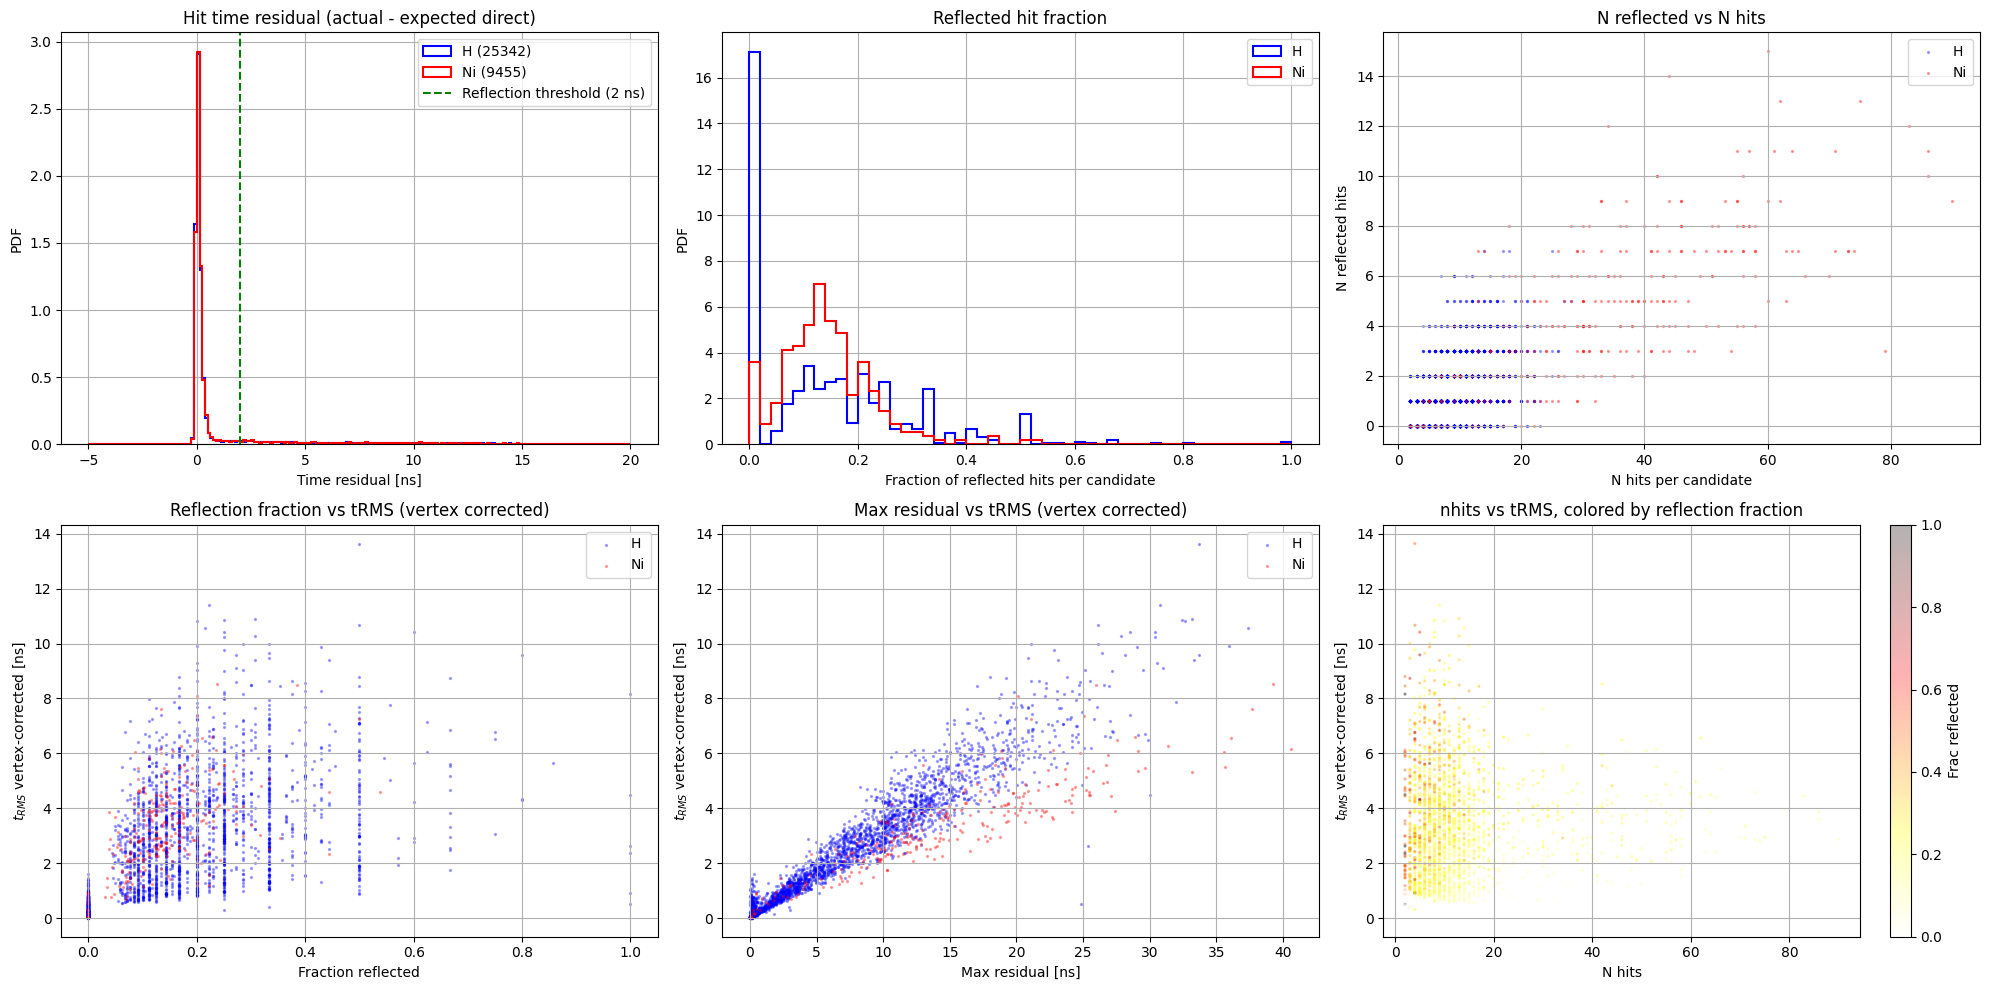

In [14]:
# --- Plots ---
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Row 1: residual distributions
all_res_H  = np.concatenate(df_refl[df_refl["capture_type"] == "H"]["residuals"].values)
all_res_Ni = np.concatenate(df_refl[df_refl["capture_type"] == "Ni"]["residuals"].values)

axes[0, 0].hist(all_res_H,  bins=200, range=(-5, 20), density=True,
                histtype='step', color='blue', linewidth=1.5, label=f'H ({len(all_res_H)})')
axes[0, 0].hist(all_res_Ni, bins=200, range=(-5, 20), density=True,
                histtype='step', color='red', linewidth=1.5, label=f'Ni ({len(all_res_Ni)})')
axes[0, 0].axvline(2.0, color='green', linestyle='--', label='Reflection threshold (2 ns)')
axes[0, 0].set_xlabel("Time residual [ns]")
axes[0, 0].set_ylabel("PDF")
axes[0, 0].set_title("Hit time residual (actual - expected direct)")
axes[0, 0].legend()
axes[0, 0].grid(True)

# Fraction reflected per candidate
axes[0, 1].hist(df_refl[df_refl["capture_type"] == "H"]["frac_reflected"], 
                bins=50, range=(0, 1), density=True, histtype='step', 
                color='blue', linewidth=1.5, label='H')
axes[0, 1].hist(df_refl[df_refl["capture_type"] == "Ni"]["frac_reflected"], 
                bins=50, range=(0, 1), density=True, histtype='step', 
                color='red', linewidth=1.5, label='Ni')
axes[0, 1].set_xlabel("Fraction of reflected hits per candidate")
axes[0, 1].set_ylabel("PDF")
axes[0, 1].set_title("Reflected hit fraction")
axes[0, 1].legend()
axes[0, 1].grid(True)

# N reflected vs nhits
axes[0, 2].scatter(df_refl[df_refl["capture_type"] == "H"]["nhits"],
                   df_refl[df_refl["capture_type"] == "H"]["n_reflected"],
                   s=2, alpha=0.3, color='blue', label='H')
axes[0, 2].scatter(df_refl[df_refl["capture_type"] == "Ni"]["nhits"],
                   df_refl[df_refl["capture_type"] == "Ni"]["n_reflected"],
                   s=2, alpha=0.3, color='red', label='Ni')
axes[0, 2].set_xlabel("N hits per candidate")
axes[0, 2].set_ylabel("N reflected hits")
axes[0, 2].set_title("N reflected vs N hits")
axes[0, 2].legend()
axes[0, 2].grid(True)

# Row 2: impact on tRMS
axes[1, 0].scatter(df_refl[df_refl["capture_type"] == "H"]["frac_reflected"],
                   df_refl[df_refl["capture_type"] == "H"]["trms_corrected_vertex"],
                   s=2, alpha=0.3, color='blue', label='H')
axes[1, 0].scatter(df_refl[df_refl["capture_type"] == "Ni"]["frac_reflected"],
                   df_refl[df_refl["capture_type"] == "Ni"]["trms_corrected_vertex"],
                   s=2, alpha=0.3, color='red', label='Ni')
axes[1, 0].set_xlabel("Fraction reflected")
axes[1, 0].set_ylabel("$t_{RMS}$ vertex-corrected [ns]")
axes[1, 0].set_title("Reflection fraction vs tRMS (vertex corrected)")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].scatter(df_refl[df_refl["capture_type"] == "H"]["max_residual"],
                   df_refl[df_refl["capture_type"] == "H"]["trms_corrected_vertex"],
                   s=2, alpha=0.3, color='blue', label='H')
axes[1, 1].scatter(df_refl[df_refl["capture_type"] == "Ni"]["max_residual"],
                   df_refl[df_refl["capture_type"] == "Ni"]["trms_corrected_vertex"],
                   s=2, alpha=0.3, color='red', label='Ni')
axes[1, 1].set_xlabel("Max residual [ns]")
axes[1, 1].set_ylabel("$t_{RMS}$ vertex-corrected [ns]")
axes[1, 1].set_title("Max residual vs tRMS (vertex corrected)")
axes[1, 1].legend()
axes[1, 1].grid(True)

# nhits vs tRMS vertex corrected, colored by frac_reflected
sc = axes[1, 2].scatter(df_refl["nhits"], df_refl["trms_corrected_vertex"], 
                         s=2, alpha=0.3, c=df_refl["frac_reflected"], cmap='hot_r')
axes[1, 2].set_xlabel("N hits")
axes[1, 2].set_ylabel("$t_{RMS}$ vertex-corrected [ns]")
axes[1, 2].set_title("nhits vs tRMS, colored by reflection fraction")
fig.colorbar(sc, ax=axes[1, 2], label="Frac reflected")
axes[1, 2].grid(True)

plt.tight_layout()
plt.show()

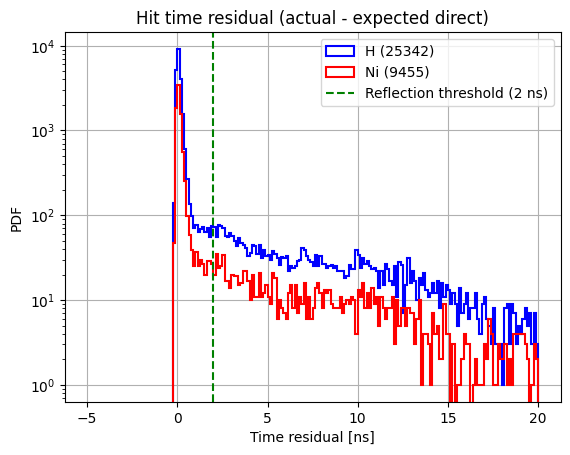

In [20]:
# Row 1: residual distributions
all_res_H  = np.concatenate(df_refl[df_refl["capture_type"] == "H"]["residuals"].values)
all_res_Ni = np.concatenate(df_refl[df_refl["capture_type"] == "Ni"]["residuals"].values)

plt.hist(all_res_H,  bins=200, range=(-5, 20), density=False, histtype='step', color='blue', linewidth=1.5, label=f'H ({len(all_res_H)})')
plt.hist(all_res_Ni, bins=200, range=(-5, 20), density=False, histtype='step', color='red', linewidth=1.5, label=f'Ni ({len(all_res_Ni)})')

plt.axvline(2.0, color='green', linestyle='--', label='Reflection threshold (2 ns)')
plt.xlabel("Time residual [ns]")
plt.ylabel("PDF")
plt.title("Hit time residual (actual - expected direct)")
plt.legend()
plt.grid(True)
plt.yscale("log");

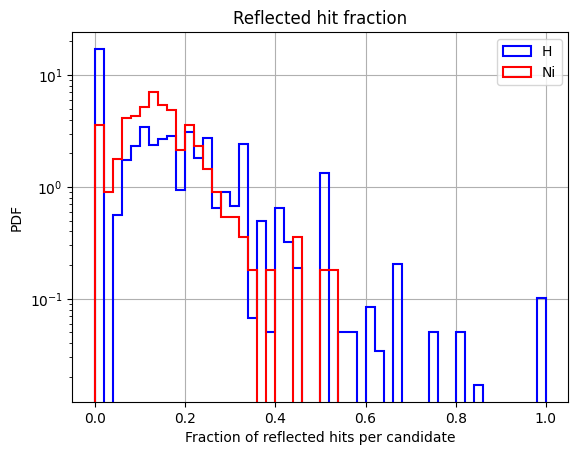

In [22]:
# Fraction reflected per candidate
plt.hist(df_refl[df_refl["capture_type"] == "H"]["frac_reflected"], bins=50, range=(0, 1), density=True, histtype='step', color='blue', linewidth=1.5, label='H')
plt.hist(df_refl[df_refl["capture_type"] == "Ni"]["frac_reflected"], bins=50, range=(0, 1), density=True, histtype='step', color='red', linewidth=1.5, label='Ni')

plt.xlabel("Fraction of reflected hits per candidate")
plt.ylabel("PDF")
plt.title("Reflected hit fraction")
plt.legend()
plt.grid(True)
plt.yscale("log");

# Number Of Gammas vs. tRMS (also energy)

In [20]:
df_cands

,Unnamed: 0,event_id,candidate_id,nhits,trms,tc,duration,seed_time,all_parents,all_pmts,all_times,capture_type,n_parents,tof_corrected_vertex_times,trms_corrected_vertex,tof_corrected_source_times,trms_corrected_source
0,0,0,0,10,4.074298,3.000000,12.855469,20284.443,[np.int32(55)],"[np.int64(59), np.int64(66), np.int64(67), np....","[np.float32(20284.443), np.float32(20284.61), ...",H,1,"[np.float32(20276.518), np.float32(20276.607),...",4.834965,"[np.float32(20275.918), np.float32(20275.973),...",4.429435
1,1,0,1,13,4.047079,2.378606,15.710938,76875.310,"[np.int32(87), np.int32(89)]","[np.int64(155), np.int64(232), np.int64(460), ...","[np.float32(76875.31), np.float32(76875.43), n...",Ni,2,"[np.float32(76869.39), np.float32(76869.266), ...",2.895136,"[np.float32(76868.39), np.float32(76868.38), n...",3.088965
2,2,0,2,13,4.575776,3.591346,16.843750,398152.940,[np.int32(74)],"[np.int64(42), np.int64(234), np.int64(345), n...","[np.float32(398152.94), np.float32(398153.16),...",H,1,"[np.float32(398147.75), np.float32(398147.75),...",3.817993,"[np.float32(398145.94), np.float32(398145.7), ...",4.165827
3,3,0,3,2,0.218750,0.218750,0.437500,493198.700,"[np.int32(39), np.int32(41)]","[np.int64(117), np.int64(181)]","[np.float32(493198.7), np.float32(493199.12)]",H,2,"[np.float32(493189.75), np.float32(493190.2)]",0.218750,"[np.float32(493190.06), np.float32(493190.62)]",0.281250
4,4,1,4,22,6.718883,7.328125,23.757812,23627.053,[np.int32(79)],"[np.int64(66), np.int64(342), np.int64(352), n...","[np.float32(23627.053), np.float32(23627.223),...",Ni,1,"[np.float32(23624.938), np.float32(23625.025),...",5.439983,"[np.float32(23623.885), np.float32(23623.998),...",5.527853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50446,50446,14998,50446,7,1.485984,1.448661,3.921875,198830.250,[np.int32(125)],"[np.int64(1258), np.int64(1482), np.int64(1518...","[np.float32(198830.25), np.float32(198830.34),...",H,1,"[np.float32(198827.75), np.float32(198827.67),...",0.087993,"[np.float32(198827.08), np.float32(198826.92),...",0.201574
50447,50447,14998,50447,16,2.784014,3.171875,10.250000,267615.340,[np.int32(114)],"[np.int64(291), np.int64(312), np.int64(1045),...","[np.float32(267615.34), np.float32(267615.47),...",H,1,"[np.float32(267613.47), np.float32(267613.4), ...",0.365605,"[np.float32(267611.84), np.float32(267611.3), ...",0.899524
50448,50448,14999,50448,11,7.012865,6.704546,23.992188,78988.380,[np.int32(67)],"[np.int64(178), np.int64(504), np.int64(754), ...","[np.float32(78988.38), np.float32(78988.414), ...",H,1,"[np.float32(78985.48), np.float32(78985.234), ...",4.543079,"[np.float32(78984.96), np.float32(78984.67), n...",4.628222
50449,50449,14999,50449,8,3.005405,3.533203,9.242188,105411.840,[np.int32(51)],"[np.int64(390), np.int64(503), np.int64(1356),...","[np.float32(105411.84), np.float32(105412.01),...",H,1,"[np.float32(105410.15), np.float32(105410.17),...",0.905336,"[np.float32(105408.71), np.float32(105408.75),...",1.682152


In [22]:
noParents = []
vCorrtRMS = []

for i in df_cands[df_cands["capture_type"].values == "Ni"].iterrows():
    noParents.append(i[1]["n_parents"])
    vCorrtRMS.append(i[1]["trms_corrected_vertex"])

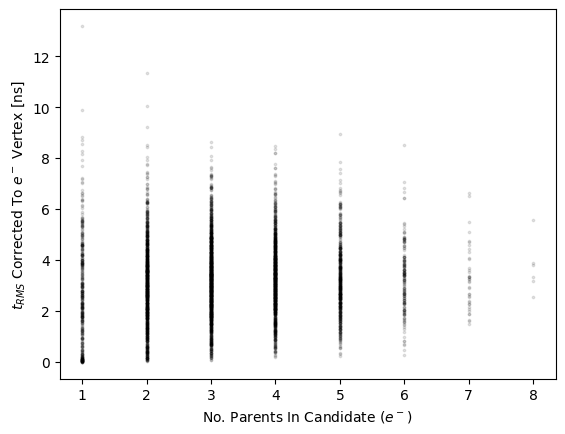

In [27]:
plt.scatter(noParents, vCorrtRMS, s=3, alpha=0.1);
plt.xlabel("No. Parents In Candidate ($e^-$)");
plt.ylabel("$t_{RMS}$ Corrected To $e^-$ Vertex [ns]");

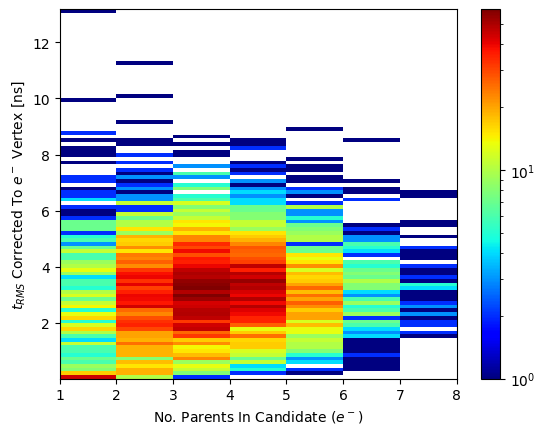

In [36]:
h = plt.hist2d(noParents, vCorrtRMS, bins=(7,100), norm="log", cmap="jet");
plt.colorbar(h[3]);

plt.xlabel("No. Parents In Candidate ($e^-$)");
plt.ylabel("$t_{RMS}$ Corrected To $e^-$ Vertex [ns]");

# Read df_mc_cands From .py Pipeline

In [3]:
df_cands_mc = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/data/df_mc_cands.csv")

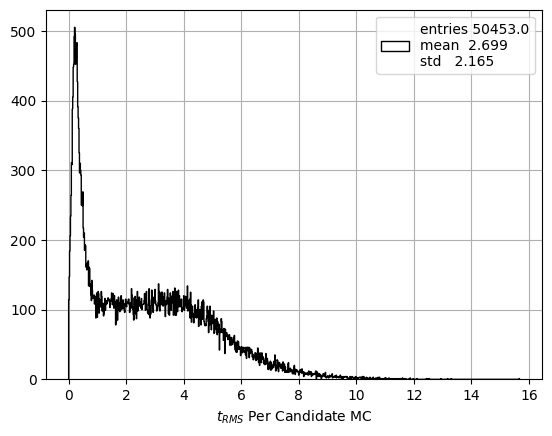

In [5]:
pltext.hist([i for i in df_cands_mc.trms if i != 0], 1000, xylabels="$t_{RMS}$ Per Candidate MC");

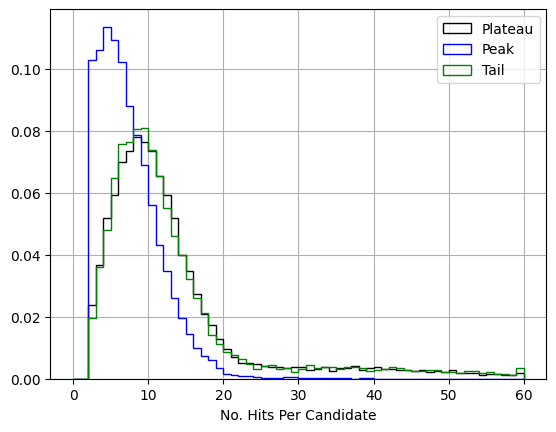

In [18]:
pltext.hist(df_cands_mc[(df_cands_mc.trms.values > 1) & (df_cands_mc.trms.values < 4)]["nhits"].values, 60, range=(0, 60), stats=False, density=True, xylabels="No. Hits Per Candidate", label="Plateau");
pltext.hist(df_cands_mc[(df_cands_mc.trms.values < 1)]["nhits"].values,                                 60, range=(0, 60), stats=False, density=True, xylabels="No. Hits Per Candidate", label="Peak");
pltext.hist(df_cands_mc[(df_cands_mc.trms.values > 4)]["nhits"].values,                                 60, range=(0, 60), stats=False, density=True, xylabels="No. Hits Per Candidate", label="Tail");

In [3]:
df_cands_sig = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/data/trms2nhits2/df_sig_R1767.csv")
df_cands_bkg = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/data/trms2nhits2/df_bkg_R1766.csv")

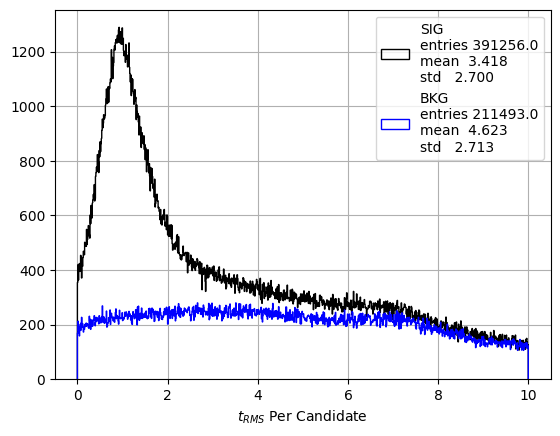

In [58]:
pltext.hist(df_cands_sig.groupby("candidate_id")["trms"].first().values, 1000, range=(0,10), xylabels="$t_{RMS}$ Per Candidate", label="SIG");
pltext.hist(df_cands_bkg.groupby("candidate_id")["trms"].first().values, 1000, range=(0,10), xylabels="$t_{RMS}$ Per Candidate", label="BKG");

In [39]:
resumen_sig = df_cands_sig.groupby('candidate_id').agg(
    nhits =('candidate_id', 'size'),
    trms  =('trms', 'first')
).reset_index()

resumen_bkg = df_cands_bkg.groupby('candidate_id').agg(
    nhits =('candidate_id', 'size'),
    trms  =('trms', 'first')
).reset_index()

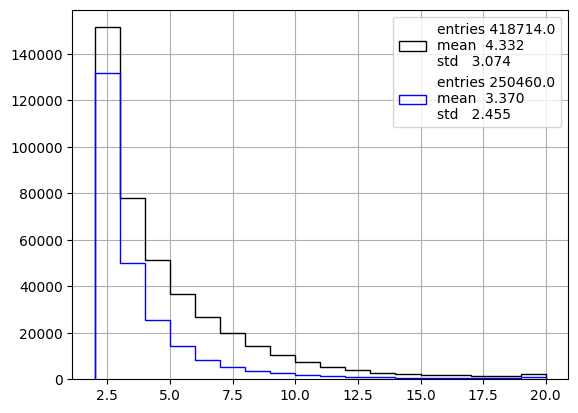

In [48]:
pltext.hist(resumen_sig.nhits, 18, range=(2, 20), ylog=False);
pltext.hist(resumen_bkg.nhits, 18, range=(2, 20), ylog=False);

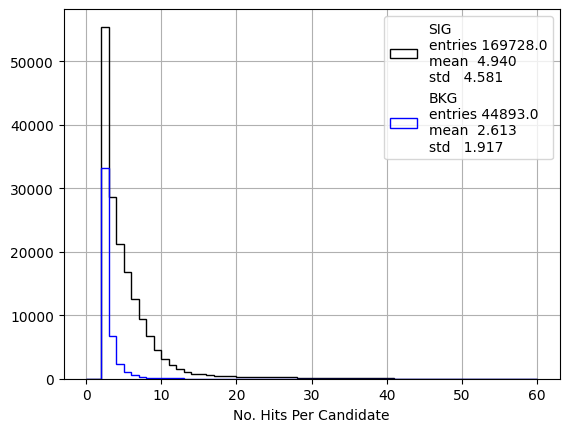

In [57]:
pltext.hist(resumen_sig[resumen_sig["trms"].values <= 2].nhits, 60, range=(0, 60), ylog=False, xylabels="No. Hits Per Candidate", label="SIG");
pltext.hist(resumen_bkg[resumen_bkg["trms"].values <= 2].nhits, 60, range=(0, 60), ylog=False, xylabels="No. Hits Per Candidate", label="BKG");

In [6]:
df_sig_cut = df_cands_sig[df_cands_sig["trms"] < 2]
df_bkg_cut = df_cands_bkg[df_cands_bkg["trms"] < 2]

In [29]:
common_events = np.intersect1d(df_sig_cut["event_id"].unique(), df_bkg_cut["event_id"].unique())

In [31]:
df_sig_matched = df_sig_cut[df_sig_cut["event_id"].isin(common_events)]
df_bkg_matched = df_bkg_cut[df_bkg_cut["event_id"].isin(common_events)]

In [32]:
def hits_per_pmt(pmt_ids, n_pmts=2014):
    result = np.zeros(n_pmts)
    ids, counts = np.unique(pmt_ids[pmt_ids < n_pmts], return_counts=True)
    result[ids.astype(int)] = counts
    return result

sig_hits = hits_per_pmt(df_sig_matched["pmt_id"].values)
bkg_hits = hits_per_pmt(df_bkg_matched["pmt_id"].values)
pure_signal = sig_hits - bkg_hits
pure_signal[pure_signal < 0] = 0

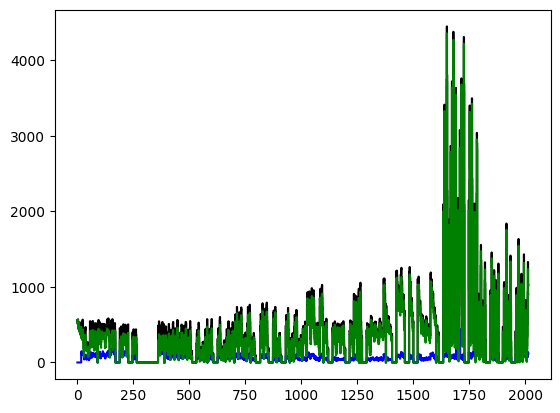

In [ ]:
plt.step(range(2014), sig_hits);
plt.step(range(2014), bkg_hits);
plt.step(range(2014), pure_signal);

In [4]:
df_qe = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/analysis_files/final_pipeline_claude/data/trms2nhits2/relative_qe.csv")
df_qe

,pmt_id,relative_qe,error_qe,data_hits,mc_hits
0,0,1.136990,0.126144,561.0,95.0
1,1,1.070514,0.116280,556.0,100.0
2,2,1.050768,0.117890,513.0,94.0
3,3,1.165472,0.129759,569.0,94.0
4,4,1.211201,0.140605,541.0,86.0
...,...,...,...,...,...
2009,2009,1.155231,0.224110,186.0,31.0
2010,2010,0.650038,0.070886,368.0,109.0
2011,2011,0.841501,0.066460,861.0,197.0
2012,2012,0.955733,0.066388,1236.0,249.0


0.864456127699297 0.34082743596806375


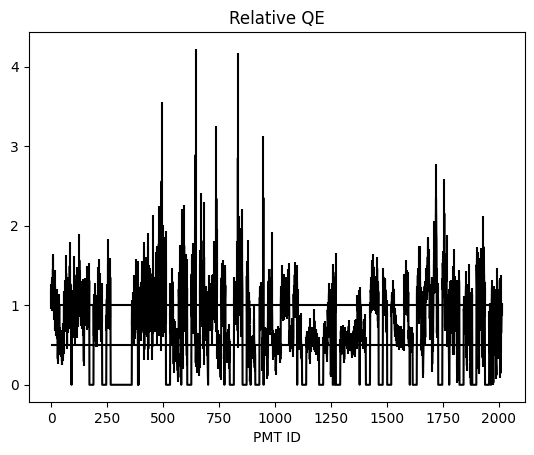

In [107]:
plt.errorbar(range(2014), df_qe.relative_qe, df_qe.error_qe);
plt.hlines(0.5, 0, 2014);
plt.hlines(1.0, 0, 2014);
plt.title("Relative QE");
plt.xlabel("PMT ID");

print(np.mean([i for i in df_qe.relative_qe if i!=0]), np.std([i for i in df_qe.relative_qe if i!=0]))

In [80]:
std  = np.std([i for i in df_qe.relative_qe if i!=0])

df_qe[(df_qe["relative_qe"].values >= 0.5-std) & ((df_qe["relative_qe"].values <= 0.5+std))]

,pmt_id,relative_qe,error_qe,data_hits,mc_hits
18,18,0.792370,0.100026,321.0,78.0
19,19,0.760330,0.085981,387.0,98.0
21,21,0.725228,0.085997,339.0,90.0
22,22,0.702061,0.087517,299.0,82.0
23,23,0.787859,0.094225,356.0,87.0
...,...,...,...,...,...
1999,1999,0.821497,0.166636,128.0,30.0
2005,2005,0.595119,0.206431,34.0,11.0
2006,2006,0.417167,0.205892,13.0,6.0
2008,2008,0.516003,0.120931,67.0,25.0


# < 0.5

Selected 683 PMTs with QE in [0.159, 0.841]
(2014,)


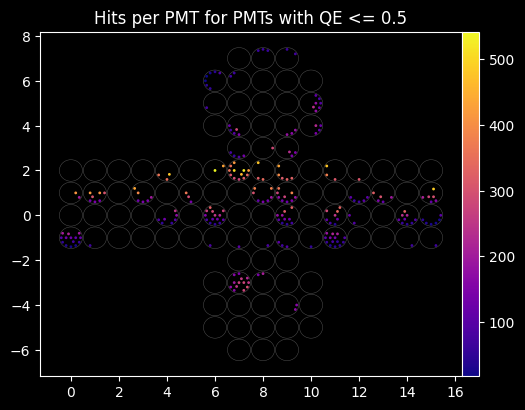

In [7]:
import matplotlib.colors as colors
from WCTE_event_display.EventDisplay import EventDisplay

# --- Setup EventDisplay ---
eventDisplay = EventDisplay()
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
eventDisplay.load_wcsim_tubeno_mapping(
    "/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt"
)

# --- Select PMTs with QE near 0.5 ---
std = np.std([i for i in df_qe.relative_qe if i != 0])
mask = (df_qe["relative_qe"].values <= 0.5)
df_selected = df_qe[mask]

print(f"Selected {len(df_selected)} PMTs with QE in [{0.5-std:.3f}, {0.5+std:.3f}]")

selected_pmt_ids = df_selected["pmt_id"].values.astype(int)

# --- Count hits per PMT only for selected PMTs ---
n_channels = 2014
hits_display = np.zeros(n_channels)

hits_per_pmt = df_sig_cut.groupby("pmt_id")["hit_pmt_charges"].count()
for pmt_id in selected_pmt_ids:
    if 0 <= pmt_id < n_channels and pmt_id in hits_per_pmt.index:
        hits_display[pmt_id] = hits_per_pmt[pmt_id]

# --- Plot with color bar = number of hits ---
vmin = hits_display[hits_display > 0].min() if (hits_display > 0).any() else 1
vmax = hits_display.max()

eventDisplay.plotEventDisplay(
    hits_display,
    color_norm=colors.Normalize(vmin=vmin, vmax=vmax),
    style="dark_background"
)
plt.title(f"Hits per PMT for PMTs with QE <= 0.5")

plt.style.use('default')
pltext.style()

Selected 683 PMTs with QE in [0.159, 0.841]
(2014,)


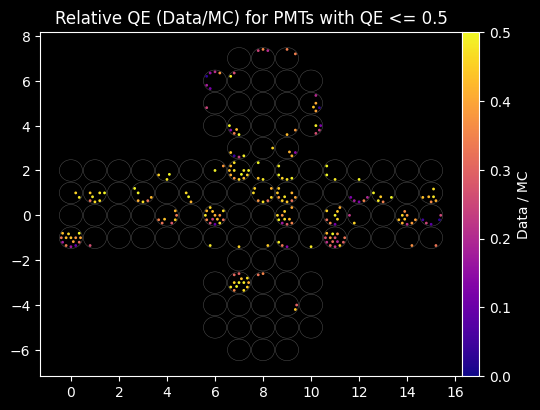

In [10]:
import matplotlib.colors as colors
from WCTE_event_display.EventDisplay import EventDisplay

# --- Setup EventDisplay ---
eventDisplay = EventDisplay()
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
eventDisplay.load_wcsim_tubeno_mapping(
    "/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt"
)

# --- Select PMTs with QE near 0.5 ---
std = np.std([i for i in df_qe.relative_qe if i != 0])
mask = (df_qe["relative_qe"].values <= 0.5)
df_selected = df_qe[mask]

print(f"Selected {len(df_selected)} PMTs with QE in [{0.5-std:.3f}, {0.5+std:.3f}]")

selected_pmt_ids = df_selected["pmt_id"].values.astype(int)

# --- Build display array with relative QE for selected PMTs ---
n_channels = 2014
qe_display = np.zeros(n_channels)

for _, row in df_selected.iterrows():
    pmt_id = int(row["pmt_id"])
    if 0 <= pmt_id < n_channels:
        qe_display[pmt_id] = row["relative_qe"]

# --- Plot with color bar = Data/MC ---
eventDisplay.plotEventDisplay(
    qe_display,
    color_norm=colors.Normalize(vmin=0, vmax=0.5),
    color_label="Data / MC",
    style="dark_background"
)
plt.title(f"Relative QE (Data/MC) for PMTs with QE <= 0.5")

plt.style.use('default')
pltext.style()

Selected 683 PMTs with QE <= 0.5
(2014,)


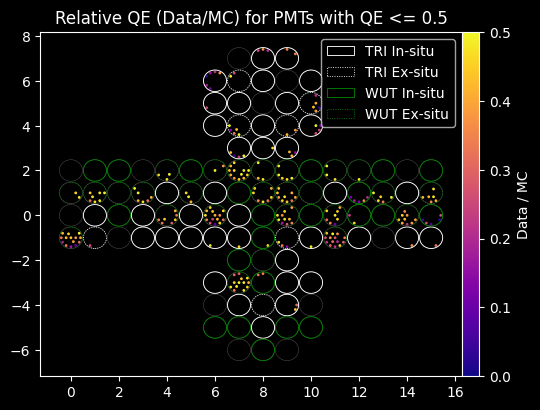

In [13]:
import matplotlib.colors as colors
import matplotlib
import pickle
from matplotlib.patches import Circle, Patch
from matplotlib.collections import PatchCollection
from WCTE_event_display.EventDisplay import EventDisplay

# --- Setup EventDisplay ---
eventDisplay = EventDisplay()
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
eventDisplay.load_wcsim_tubeno_mapping(
    "/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt"
)

# --- Select PMTs with QE <= 0.5 ---
std = np.std([i for i in df_qe.relative_qe if i != 0])
mask = (df_qe["relative_qe"].values <= 0.5)
df_selected = df_qe[mask]
print(f"Selected {len(df_selected)} PMTs with QE <= 0.5")

selected_pmt_ids = df_selected["pmt_id"].values.astype(int)

# --- Build display array with relative QE for selected PMTs ---
n_channels = 2014
qe_display = np.zeros(n_channels)

for _, row in df_selected.iterrows():
    pmt_id = int(row["pmt_id"])
    if 0 <= pmt_id < n_channels:
        qe_display[pmt_id] = row["relative_qe"]

# --- Plot with color bar = Data/MC ---
eventDisplay.plotEventDisplay(
    qe_display,
    color_norm=colors.Normalize(vmin=0, vmax=0.5),
    color_label="Data / MC",
    style="dark_background"
)
plt.title(f"Relative QE (Data/MC) for PMTs with QE <= 0.5")

# --- Load mPMT type dictionary ---
with open("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/other_mpmt_info.dict", "rb") as f:
    mpmt_info = pickle.load(f)

# --- Classify mPMTs by type and site ---
unique_mpmts = np.unique(np.arange(106))

tri_in_situ_list  = []
tri_ex_situ_list  = []
wut_in_situ_list  = []
wut_ex_situ_list  = []

for mpmt in unique_mpmts:
    if mpmt not in mpmt_info:
        continue
    mpmt_type = mpmt_info[mpmt]['mpmt_type']
    mpmt_site = mpmt_info[mpmt]['mpmt_site']
    
    if mpmt_type == 'Ex-situ' and mpmt_site == 'TRI':
        tri_ex_situ_list.append(mpmt)
    elif mpmt_type == 'In-situ' and mpmt_site == 'TRI':
        tri_in_situ_list.append(mpmt)
    elif mpmt_type == 'Ex-situ' and mpmt_site == 'WUT':
        wut_ex_situ_list.append(mpmt)
    elif mpmt_type == 'In-situ' and mpmt_site == 'WUT':
        wut_in_situ_list.append(mpmt)

# --- Draw circles around mPMTs by type ---
mpmt_groups = [tri_in_situ_list, tri_ex_situ_list, wut_in_situ_list, wut_ex_situ_list]
labels      = ["TRI In-situ", "TRI Ex-situ", "WUT In-situ", "WUT Ex-situ"]
linestyles  = ["solid", "dotted", "solid", "dotted"]
colors_list = ["white", "white", "green", "green"]

scale = matplotlib.rcParams['figure.figsize'][0] / 20
ax = plt.gca()
legend_handles = []

for group, label, ls, color in zip(mpmt_groups, labels, linestyles, colors_list):
    if len(group) == 0:
        continue
    positions = eventDisplay.mPMT_2D_projection[group, 1:3]
    circles = [Circle((pos[0], pos[1]), radius=0.48) for pos in positions]
    collection = PatchCollection(circles, facecolor="none",
                                  linewidths=2*scale, edgecolors=color, linestyles=ls)
    ax.add_collection(collection)
    legend_handles.append(Patch(facecolor="none", edgecolor=color,
                                 linestyle=ls, linewidth=2*scale, label=label))

ax.legend(handles=legend_handles)

plt.style.use('default')
pltext.style()

# 0.5 < qe < 1.0

Selected 754 PMTs with QE in [0.159, 0.841]
(2014,)


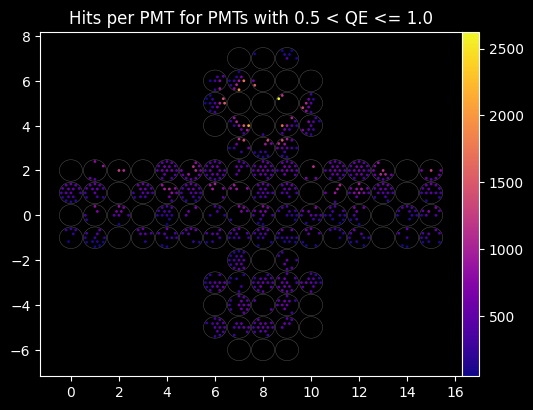

In [101]:
import matplotlib.colors as colors
from WCTE_event_display.EventDisplay import EventDisplay

# --- Setup EventDisplay ---
eventDisplay = EventDisplay()
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
eventDisplay.load_wcsim_tubeno_mapping(
    "/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt"
)

# --- Select PMTs with QE near 0.5 ---
std = np.std([i for i in df_qe.relative_qe if i != 0])
mask = (df_qe["relative_qe"].values > 0.5) & (df_qe["relative_qe"].values <= 1.0)
df_selected = df_qe[mask]

print(f"Selected {len(df_selected)} PMTs with QE in [{0.5-std:.3f}, {0.5+std:.3f}]")

selected_pmt_ids = df_selected["pmt_id"].values.astype(int)

# --- Count hits per PMT only for selected PMTs ---
n_channels = 2014
hits_display = np.zeros(n_channels)

hits_per_pmt = df_sig_cut.groupby("pmt_id")["hit_pmt_charges"].count()
for pmt_id in selected_pmt_ids:
    if 0 <= pmt_id < n_channels and pmt_id in hits_per_pmt.index:
        hits_display[pmt_id] = hits_per_pmt[pmt_id]

# --- Plot with color bar = number of hits ---
vmin = hits_display[hits_display > 0].min() if (hits_display > 0).any() else 1
vmax = hits_display.max()

eventDisplay.plotEventDisplay(
    hits_display,
    color_norm=colors.Normalize(vmin=vmin, vmax=vmax),
    style="dark_background"
)
plt.title(f"Hits per PMT for PMTs with 0.5 < QE <= 1.0")

plt.style.use('default')
pltext.style()

Selected 754 PMTs with QE in [0.159, 0.841]
(2014,)


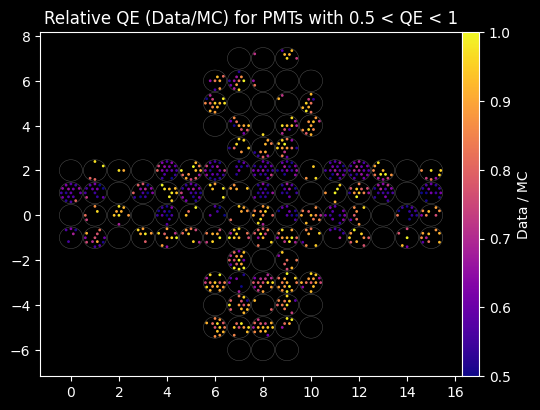

In [11]:
import matplotlib.colors as colors
from WCTE_event_display.EventDisplay import EventDisplay

# --- Setup EventDisplay ---
eventDisplay = EventDisplay()
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
eventDisplay.load_wcsim_tubeno_mapping(
    "/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt"
)

# --- Select PMTs with QE near 0.5 ---
std = np.std([i for i in df_qe.relative_qe if i != 0])
mask = (df_qe["relative_qe"].values > 0.5) & (df_qe["relative_qe"].values <= 1.0)
df_selected = df_qe[mask]

print(f"Selected {len(df_selected)} PMTs with QE in [{0.5-std:.3f}, {0.5+std:.3f}]")

selected_pmt_ids = df_selected["pmt_id"].values.astype(int)

# --- Build display array with relative QE for selected PMTs ---
n_channels = 2014
qe_display = np.zeros(n_channels)

for _, row in df_selected.iterrows():
    pmt_id = int(row["pmt_id"])
    if 0 <= pmt_id < n_channels:
        qe_display[pmt_id] = row["relative_qe"]

# --- Plot with color bar = Data/MC ---
eventDisplay.plotEventDisplay(
    qe_display,
    color_norm=colors.Normalize(vmin=0.5, vmax=1.0),
    color_label="Data / MC",
    style="dark_background"
)
plt.title(f"Relative QE (Data/MC) for PMTs with 0.5 < QE < 1")

plt.style.use('default')
pltext.style()

Selected 754 PMTs with 0.5 < QE < 1.0
(2014,)


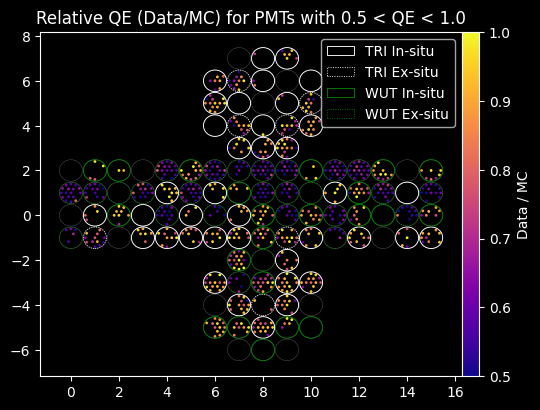

In [14]:
import matplotlib.colors as colors
import matplotlib
import pickle
from matplotlib.patches import Circle, Patch
from matplotlib.collections import PatchCollection
from WCTE_event_display.EventDisplay import EventDisplay

# --- Setup EventDisplay ---
eventDisplay = EventDisplay()
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
eventDisplay.load_wcsim_tubeno_mapping(
    "/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt"
)

# --- Select PMTs with 0.5 <= QE <= 1.0 ---
std = np.std([i for i in df_qe.relative_qe if i != 0])
mask = (df_qe["relative_qe"].values > 0.5) & (df_qe["relative_qe"].values < 1.0)
df_selected = df_qe[mask]
print(f"Selected {len(df_selected)} PMTs with 0.5 < QE < 1.0")

selected_pmt_ids = df_selected["pmt_id"].values.astype(int)

# --- Build display array with relative QE for selected PMTs ---
n_channels = 2014
qe_display = np.zeros(n_channels)

for _, row in df_selected.iterrows():
    pmt_id = int(row["pmt_id"])
    if 0 <= pmt_id < n_channels:
        qe_display[pmt_id] = row["relative_qe"]

# --- Plot with color bar = Data/MC ---
eventDisplay.plotEventDisplay(
    qe_display,
    color_norm=colors.Normalize(vmin=0.5, vmax=1.0),
    color_label="Data / MC",
    style="dark_background"
)
plt.title(f"Relative QE (Data/MC) for PMTs with 0.5 < QE < 1.0")

# --- Load mPMT type dictionary ---
with open("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/other_mpmt_info.dict", "rb") as f:
    mpmt_info = pickle.load(f)

# --- Classify mPMTs by type and site ---
unique_mpmts = np.unique(np.arange(106))

tri_in_situ_list  = []
tri_ex_situ_list  = []
wut_in_situ_list  = []
wut_ex_situ_list  = []

for mpmt in unique_mpmts:
    if mpmt not in mpmt_info:
        continue
    mpmt_type = mpmt_info[mpmt]['mpmt_type']
    mpmt_site = mpmt_info[mpmt]['mpmt_site']
    
    if mpmt_type == 'Ex-situ' and mpmt_site == 'TRI':
        tri_ex_situ_list.append(mpmt)
    elif mpmt_type == 'In-situ' and mpmt_site == 'TRI':
        tri_in_situ_list.append(mpmt)
    elif mpmt_type == 'Ex-situ' and mpmt_site == 'WUT':
        wut_ex_situ_list.append(mpmt)
    elif mpmt_type == 'In-situ' and mpmt_site == 'WUT':
        wut_in_situ_list.append(mpmt)

# --- Draw circles around mPMTs by type ---
mpmt_groups = [tri_in_situ_list, tri_ex_situ_list, wut_in_situ_list, wut_ex_situ_list]
labels      = ["TRI In-situ", "TRI Ex-situ", "WUT In-situ", "WUT Ex-situ"]
linestyles  = ["solid", "dotted", "solid", "dotted"]
colors_list = ["white", "white", "green", "green"]

scale = matplotlib.rcParams['figure.figsize'][0] / 20
ax = plt.gca()
legend_handles = []

for group, label, ls, color in zip(mpmt_groups, labels, linestyles, colors_list):
    if len(group) == 0:
        continue
    positions = eventDisplay.mPMT_2D_projection[group, 1:3]
    circles = [Circle((pos[0], pos[1]), radius=0.48) for pos in positions]
    collection = PatchCollection(circles, facecolor="none",
                                  linewidths=2*scale, edgecolors=color, linestyles=ls)
    ax.add_collection(collection)
    legend_handles.append(Patch(facecolor="none", edgecolor=color,
                                 linestyle=ls, linewidth=2*scale, label=label))

ax.legend(handles=legend_handles)

plt.style.use('default')
pltext.style()

# > 1.0

Selected 577 PMTs with QE in [0.159, 0.841]
(2014,)


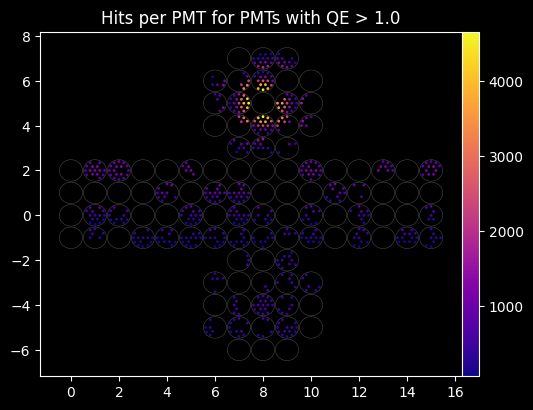

In [102]:
import matplotlib.colors as colors
from WCTE_event_display.EventDisplay import EventDisplay

# --- Setup EventDisplay ---
eventDisplay = EventDisplay()
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
eventDisplay.load_wcsim_tubeno_mapping(
    "/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt"
)

# --- Select PMTs with QE near 0.5 ---
std = np.std([i for i in df_qe.relative_qe if i != 0])
mask = (df_qe["relative_qe"].values > 1.0)
df_selected = df_qe[mask]

print(f"Selected {len(df_selected)} PMTs with QE in [{0.5-std:.3f}, {0.5+std:.3f}]")

selected_pmt_ids = df_selected["pmt_id"].values.astype(int)

# --- Count hits per PMT only for selected PMTs ---
n_channels = 2014
hits_display = np.zeros(n_channels)

hits_per_pmt = df_sig_cut.groupby("pmt_id")["hit_pmt_charges"].count()
for pmt_id in selected_pmt_ids:
    if 0 <= pmt_id < n_channels and pmt_id in hits_per_pmt.index:
        hits_display[pmt_id] = hits_per_pmt[pmt_id]

# --- Plot with color bar = number of hits ---
vmin = hits_display[hits_display > 0].min() if (hits_display > 0).any() else 1
vmax = hits_display.max()

eventDisplay.plotEventDisplay(
    hits_display,
    color_norm=colors.Normalize(vmin=vmin, vmax=vmax),
    style="dark_background"
)
plt.title(f"Hits per PMT for PMTs with QE > 1.0")

plt.style.use('default')
pltext.style()

Selected 577 PMTs with QE in [0.159, 0.841]
(2014,)


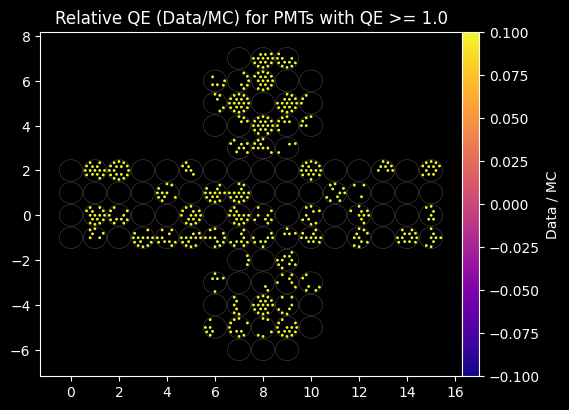

In [12]:
import matplotlib.colors as colors
from WCTE_event_display.EventDisplay import EventDisplay

# --- Setup EventDisplay ---
eventDisplay = EventDisplay()
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
eventDisplay.load_wcsim_tubeno_mapping(
    "/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt"
)

# --- Select PMTs with QE near 0.5 ---
std = np.std([i for i in df_qe.relative_qe if i != 0])
mask = (df_qe["relative_qe"].values >= 1)
df_selected = df_qe[mask]

print(f"Selected {len(df_selected)} PMTs with QE in [{0.5-std:.3f}, {0.5+std:.3f}]")

selected_pmt_ids = df_selected["pmt_id"].values.astype(int)

# --- Build display array with relative QE for selected PMTs ---
n_channels = 2014
qe_display = np.zeros(n_channels)

for _, row in df_selected.iterrows():
    pmt_id = int(row["pmt_id"])
    if 0 <= pmt_id < n_channels:
        qe_display[pmt_id] = row["relative_qe"]

# --- Plot with color bar = Data/MC ---
eventDisplay.plotEventDisplay(
    qe_display,
    color_norm=colors.Normalize(vmin=1.0, vmax=np.inf),
    color_label="Data / MC",
    style="dark_background"
)
plt.title(f"Relative QE (Data/MC) for PMTs with QE >= 1.0")

plt.style.use('default')
pltext.style()

Selected 577 PMTs with QE >= 1.0
(2014,)


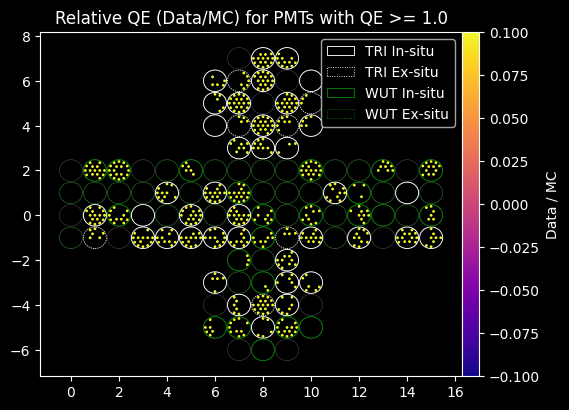

In [15]:
import matplotlib.colors as colors
import matplotlib
import pickle
from matplotlib.patches import Circle, Patch
from matplotlib.collections import PatchCollection
from WCTE_event_display.EventDisplay import EventDisplay

# --- Setup EventDisplay ---
eventDisplay = EventDisplay()
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
eventDisplay.load_wcsim_tubeno_mapping(
    "/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt"
)

# --- Select PMTs with QE >= 1.0 ---
std = np.std([i for i in df_qe.relative_qe if i != 0])
mask = (df_qe["relative_qe"].values >= 1.0)
df_selected = df_qe[mask]
print(f"Selected {len(df_selected)} PMTs with QE >= 1.0")

selected_pmt_ids = df_selected["pmt_id"].values.astype(int)

# --- Build display array with relative QE for selected PMTs ---
n_channels = 2014
qe_display = np.zeros(n_channels)

for _, row in df_selected.iterrows():
    pmt_id = int(row["pmt_id"])
    if 0 <= pmt_id < n_channels:
        qe_display[pmt_id] = row["relative_qe"]

# --- Plot with color bar = Data/MC ---
eventDisplay.plotEventDisplay(
    qe_display,
    color_norm=colors.Normalize(vmin=1.0, vmax=np.inf),
    color_label="Data / MC",
    style="dark_background"
)
plt.title(f"Relative QE (Data/MC) for PMTs with QE >= 1.0")

# --- Load mPMT type dictionary ---
with open("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/other_mpmt_info.dict", "rb") as f:
    mpmt_info = pickle.load(f)

# --- Classify mPMTs by type and site ---
unique_mpmts = np.unique(np.arange(106))

tri_in_situ_list  = []
tri_ex_situ_list  = []
wut_in_situ_list  = []
wut_ex_situ_list  = []

for mpmt in unique_mpmts:
    if mpmt not in mpmt_info:
        continue
    mpmt_type = mpmt_info[mpmt]['mpmt_type']
    mpmt_site = mpmt_info[mpmt]['mpmt_site']
    
    if mpmt_type == 'Ex-situ' and mpmt_site == 'TRI':
        tri_ex_situ_list.append(mpmt)
    elif mpmt_type == 'In-situ' and mpmt_site == 'TRI':
        tri_in_situ_list.append(mpmt)
    elif mpmt_type == 'Ex-situ' and mpmt_site == 'WUT':
        wut_ex_situ_list.append(mpmt)
    elif mpmt_type == 'In-situ' and mpmt_site == 'WUT':
        wut_in_situ_list.append(mpmt)

# --- Draw circles around mPMTs by type ---
mpmt_groups = [tri_in_situ_list, tri_ex_situ_list, wut_in_situ_list, wut_ex_situ_list]
labels      = ["TRI In-situ", "TRI Ex-situ", "WUT In-situ", "WUT Ex-situ"]
linestyles  = ["solid", "dotted", "solid", "dotted"]
colors_list = ["white", "white", "green", "green"]

scale = matplotlib.rcParams['figure.figsize'][0] / 20
ax = plt.gca()
legend_handles = []

for group, label, ls, color in zip(mpmt_groups, labels, linestyles, colors_list):
    if len(group) == 0:
        continue
    positions = eventDisplay.mPMT_2D_projection[group, 1:3]
    circles = [Circle((pos[0], pos[1]), radius=0.48) for pos in positions]
    collection = PatchCollection(circles, facecolor="none",
                                  linewidths=2*scale, edgecolors=color, linestyles=ls)
    ax.add_collection(collection)
    legend_handles.append(Patch(facecolor="none", edgecolor=color,
                                 linestyle=ls, linewidth=2*scale, label=label))

ax.legend(handles=legend_handles)

plt.style.use('default')
pltext.style()

# Others

(2014,)
(2014,)


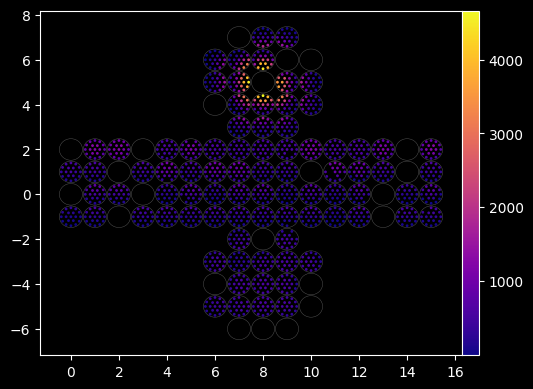

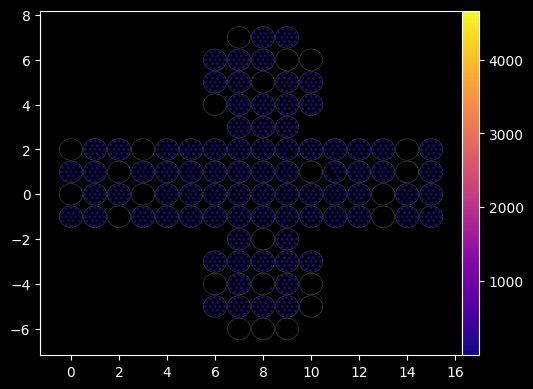

In [93]:
import matplotlib.colors as colors

n_pmts = 2014

# --- Calculamos la escala global según df_sig ---
nhits_sig = df_sig_cut.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
vmin = 1e-1  # mínimo positivo para LogNorm (evitar log(0))
vmax = nhits_sig.max() # máximo para escalar

# --- df_sig ---
eventDisplay.plotEventDisplay(
    nhits_sig,
    color_norm=colors.Normalize(vmin=vmin, vmax=vmax),
    style="dark_background"
)

# --- df_bkg ---
nhits_bkg = df_bkg_cut.groupby("pmt_id")["hit_pmt_charges"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)
eventDisplay.plotEventDisplay(
    nhits_bkg,
    color_norm=colors.Normalize(vmin=vmin, vmax=vmax),
    style="dark_background"
)

plt.style.use('default');
pltext.style()

In [90]:
df_cands_sig

,event_id,candidate_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_slot_ids,hit_pmt_position_ids,pmt_id,run,trms,nhits,tc,duration,hit_pmt_charges_calibrated
0,0,0,53680.671765,100.0,22,10,428,sig,2.202892,2,1.557680,3.115360,61.191499
1,0,0,53683.787124,117.0,3,13,70,sig,2.202892,2,1.557680,3.115360,73.422744
2,0,1,63479.663380,83.0,1,5,24,sig,9.289922,3,5.723988,16.442802,49.872649
3,0,1,63480.392541,133.0,46,12,886,sig,9.289922,3,5.723988,16.442802,116.175496
4,0,1,63496.106182,180.0,8,5,157,sig,9.289922,3,5.723988,16.442802,106.511881
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7959780,11112,450310,501599.767578,179.0,44,3,839,sig,2.925275,29,2.632098,14.058399,145.551410
7959781,11112,450310,501600.053981,75.0,103,12,1969,sig,2.925275,29,2.632098,14.058399,162.042194
7959782,11112,450310,501603.700674,113.0,101,3,1922,sig,2.925275,29,2.632098,14.058399,242.958958
7959783,11112,450310,501603.910462,192.0,43,5,822,sig,2.925275,29,2.632098,14.058399,189.307571


In [4]:
npz_1767 = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/1Mneutrons_NiCf_piFix_QGSP_BIC_HP_pos1767_CDSON_30901events_newTuning.npz'

# Creación del DataFrame de DigiHits usando la función digihits_info_to_df
df_trueHits_1767 = truehits_info_to_df(npz_1767).dropna()
# df_tracks_1767   = track_info_to_df(npz_1767).dropna()

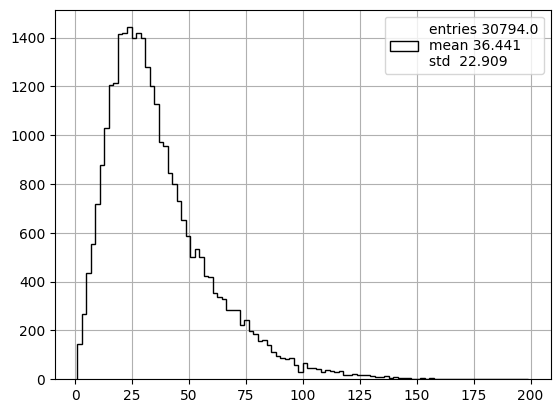

In [8]:
pltext.hist(df_trueHits_1767.groupby("event_id")["true_hit_parent"].count(), 100);

In [6]:
npz_1770 = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/1Mneutrons_NiCf_piFix_QGSP_BIC_HP_pos1770_CDSON_30901events_newTuning.npz'
df_trueHits_1770 = truehits_info_to_df(npz_1770).dropna()

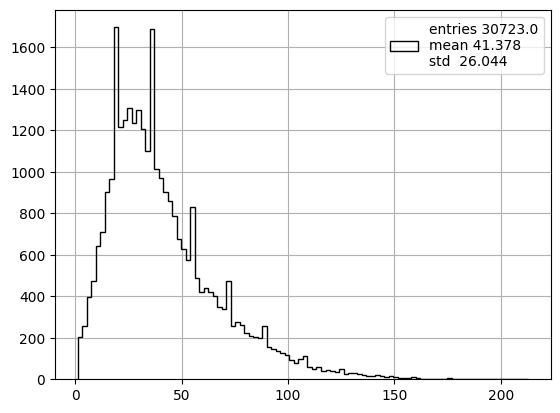

In [9]:
pltext.hist(df_trueHits_1770.groupby("event_id")["true_hit_parent"].count(), 100);